In [120]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
%autoreload 2
from utils import (
    select_users_by_period,
    create_hourly_user_dataset,
    compute_position_metrics,
)
from visualization_utils import (
    plot_market_features,
    plot_user_metrics,
)
# from visualization_utils import plot_user_metrics



In [133]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")
# =============================================================================
# HELPER FUNCTIONS (unchanged logic)
# =============================================================================

def add_leverage_factor(df_actions, window_hours=24):
    """
    Add a 'leverage_factor' column to each user's actions.
    Leverage factor = 1 + (number of 'borrow_more_w_collateral' events within window_hours after position_open) // 2
    """
    df = df_actions.sort_values(['user_address', 'timestamp']).copy()
    
    open_times = df[df['event_sequence_type'] == 'position_open'].groupby('user_address')['timestamp'].first().to_dict()
    
    leverage = {}
    for user, open_ts in open_times.items():
        user_df = df[df['user_address'] == user]
        window_end = open_ts + window_hours * 3600
        events = user_df[(user_df['timestamp'] >= open_ts) & (user_df['timestamp'] <= window_end)]
        count = len(events[events['event_sequence_type'] == 'borrow_more_w_collateral'])
        leverage[user] = 1 + count // 2
    
    df['leverage_factor'] = df['user_address'].map(leverage).fillna(1).astype(int)
    return df

def get_users_with_leverage(df_actions, start_date, end_date, window_hours=24, threshold_date=None):
    filtered_actions = select_users_by_period(df_actions, start_date, end_date, threshold_date)
    
    open_events = filtered_actions[filtered_actions['event_sequence_type'] == 'position_open'][['user_address', 'timestamp']].copy()
    open_events = open_events.rename(columns={'timestamp': 'open_time'})
    
    leverage_counts = []
    for user in open_events['user_address'].unique():
        user_open = open_events[open_events['user_address'] == user]['open_time'].iloc[0]
        user_df = filtered_actions[filtered_actions['user_address'] == user]
        
        window_end = user_open + window_hours * 3600
        window_events = user_df[(user_df['timestamp'] >= user_open) & (user_df['timestamp'] <= window_end)]
        
        leverage_count = len(window_events[window_events['event_sequence_type'] == 'borrow_more_w_collateral']) // 2
        leverage_counts.append({'user_address': user, 'leverage_factor': leverage_count})
    
    leverage_df = pd.DataFrame(leverage_counts)
    result = filtered_actions.merge(leverage_df, on='user_address', how='left')
    result["leverage_factor"] += 1

    if threshold_date is not None:
        result = result[result["datetime"].astype(str) < str(threshold_date)]
    
    return result

def add_time_difference_features(hourly_df, lookback_hours=[3, 6], diff_fields=['ltv', 'collateral_price', 'market_utilization', 'borrow_rate']):
    df = hourly_df.sort_values(['user_address', 'timestamp']).copy()
    
    open_times = df.groupby('user_address')['timestamp'].min().reset_index()
    open_times.columns = ['user_address', 'open_timestamp']
    df = df.merge(open_times, on='user_address', how='left')
    
    open_values = df[df['timestamp'] == df['open_timestamp']].copy()
    open_values_dict = {}
    for field in diff_fields:
        open_values_dict[f'open_{field}'] = open_values.set_index('user_address')[field].to_dict()
    
    for field in diff_fields:
        df[f'{field}_vs_open'] = df.apply(
            lambda row: row[field] - open_values_dict[f'open_{field}'].get(row['user_address'], 0), 
            axis=1
        )
    
    for hours in lookback_hours:
        for field in diff_fields:
            df[f'{field}_{hours}h_ago'] = df.groupby('user_address')[field].shift(hours)
            df[f'{field}_vs_{hours}h'] = df[field] - df[f'{field}_{hours}h_ago']
            df = df.drop(columns=[f'{field}_{hours}h_ago'])
    
    df = df.drop(columns=['open_timestamp'])
    return df.fillna(0)

leave_reasons = []
def remove_similar_hours(hourly_df, diff_thresholds, min_events_cnt=5):
    global leave_reasons
    leave_reasons = []
    df = hourly_df.sort_values(['user_address', 'timestamp']).copy()
    result_dfs = []
    
    for user, user_df in df.groupby('user_address'):
        action_mask = user_df['action'] != 'none'
        keep_indices = set(user_df[action_mask].index)
        
        last_kept_idx = None
        
        for idx, curr_row in user_df.iterrows():
            if idx in keep_indices or last_kept_idx is None:
                keep_indices.add(idx)
                last_kept_idx = idx
                continue
            
            prev_row = user_df.loc[last_kept_idx]
            similar = True
            for col, threshold in diff_thresholds.items():
                if col in curr_row and col in prev_row:
                    diff = abs(curr_row[col] - prev_row[col])
                    if diff > threshold:
                        leave_reasons.append(col)
                        similar = False
                        break
            if not similar:
                keep_indices.add(idx)
                last_kept_idx = idx
        
        if len(keep_indices) < min_events_cnt:
            keep_indices = set(user_df[action_mask].index)
        
        if keep_indices:
            result_dfs.append(user_df.loc[list(keep_indices)])
    
    return pd.concat(result_dfs).sort_values(['user_address', 'timestamp'])

def create_model_dataset(hourly_user_df, target_horizon_hours=1, leverage_factor_min=1, liq_threshold=0.86):
    df = hourly_user_df.sort_values(['user_address', 'timestamp']).copy()
    
    if leverage_factor_min > 0:
        df = df[df["leverage_factor"] >= leverage_factor_min]
    
    df["log_debt"] = np.log1p(df["debt"])
    df['has_action'] = (df['action'] != 'none').astype(int)
    
    open_times = df.groupby('user_address')['timestamp'].min().rename('open_timestamp')
    df = df.join(open_times, on='user_address')
    df['days_since_open'] = (df['timestamp'] - df['open_timestamp']) / 3600.0 / 24.0
    
    def compute_hours_since_last_action(group):
        group = group.sort_values('timestamp')
        last_action_ts = None
        res = []
        for ts, action in zip(group['timestamp'], group['has_action']):
            if action == 1:
                res.append(0.0)
                last_action_ts = ts
            else:
                if last_action_ts is None:
                    res.append(1000.0)
                else:
                    res.append((ts - last_action_ts) / 3600.0)
        return pd.Series(res, index=group.index)
    
    df['days_since_last_action'] = df.groupby('user_address', group_keys=False).apply(compute_hours_since_last_action) // 12
    
    def action_count_last_n_hours(group, window_hours=6):
        group = group.sort_values('timestamp')
        timestamps = group['timestamp'].values
        actions = group['has_action'].values
        counts = []
        for i, ts in enumerate(timestamps):
            start = ts - window_hours * 3600
            left = np.searchsorted(timestamps, start, side='left')
            count = np.sum(actions[left:i])
            counts.append(count)
        return pd.Series(counts, index=group.index)
    
    df['action_count_last_6h'] = df.groupby('user_address', group_keys=False).apply(
        lambda g: action_count_last_n_hours(g, 6)
    )
    
    df['ltv_change_1h'] = df.groupby('user_address')['ltv'].diff(1)
    df['distance_to_liq'] = np.maximum(liq_threshold - df['ltv'], 0)
    
    if 'borrow_rate_rolling' in df.columns:
        df['borrow_rate_trend'] = df['borrow_rate'] - df['borrow_rate_rolling']
    else:
        df['borrow_rate_trend'] = df.groupby('user_address')['borrow_rate'].transform(
            lambda x: x - x.rolling(6, min_periods=1).mean()
        )
    
    df['ltv_times_rate'] = df['ltv'] * df['borrow_rate']
    df['debt_change_1h'] = df.groupby('user_address')['debt'].diff(1)
    df['volatility_ltv'] = df['volatility_6h'] * df['ltv']
    df['hour_of_day'] = pd.to_datetime(df['timestamp'], unit='s').dt.hour
    df['day_of_week'] = pd.to_datetime(df['timestamp'], unit='s').dt.dayofweek
    
    def has_action_in_future(group):
        results = []
        timestamps = group['timestamp'].values
        actions = group['has_action'].values
        for i in range(len(group) - 1):
            current_ts = timestamps[i]
            horizon_ts = current_ts + target_horizon_hours * 3600
            future_indices = [j for j in range(i+1, len(group)) if timestamps[j] <= horizon_ts]
            results.append(1 if future_indices and any(actions[future_indices]) else 0)
        results.append(0)
        return pd.Series(results, index=group.index)
    
    df['action_next'] = df.groupby('user_address', group_keys=False).apply(has_action_in_future)
    
    features = [
        "borrow_rate_vs_open",
        "ltv_vs_open",
        "collateral_price_vs_open",
        "collateral_price_vs_6h",
        "volatility_6h",
        "drawdown_6h",
        "hours_since_open",
        "hours_since_last_action",
        "action_count_last_6h",
        "ltv_change_1h",
        "distance_to_liq",
        "borrow_rate_trend",
        "ltv_times_rate",
        "debt_change_1h",
        "volatility_ltv",
        "hour_of_day",
        "day_of_week",
        "log_debt",
    ]
    features = [f for f in features if f in df.columns]
    
    return df[['user_address', 'timestamp'] + features + ['action_next']].fillna(0)

def prepare_features(df):
    df = df.copy()
    categorical_cols = ['hour_of_day', 'day_of_week']
    feature_cols = [col for col in df.columns if col not in ['user_address', 'timestamp', 'action_next']]
    
    for col in categorical_cols:
        if col in feature_cols:
            feature_cols.remove(col)
    
    if 'ltv' in df.columns:
        df['ltv_squared'] = df['ltv'] ** 2
        feature_cols.append('ltv_squared')
    
    if 'ltv' in df.columns and 'hours_since_open' in df.columns:
        df['ltv_time'] = df['ltv'] * df['hours_since_open']
        feature_cols.append('ltv_time')
    
    if 'distance_to_liq' in df.columns:
        df['log_dist_to_liq'] = np.log1p(df['distance_to_liq'])
        feature_cols.append('log_dist_to_liq')
    
    if 'ltv_times_rate' not in feature_cols and 'ltv' in df.columns and 'borrow_rate' in df.columns:
        df['ltv_times_rate'] = df['ltv'] * df['borrow_rate']
        feature_cols.append('ltv_times_rate')
    
    dummies = pd.get_dummies(df[categorical_cols], drop_first=True)
    dummy_names = dummies.columns.tolist()
    
    X = pd.concat([df[feature_cols], dummies], axis=1)
    y = df['action_next'].copy()
    
    feature_names = feature_cols + dummy_names
    return X, y, feature_names, dummy_names

def train_logistic_model_statsmodels(model_df, verbose=True):
    X, y, feature_names, dummy_columns = prepare_features(model_df)
    
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    
    for col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_sm = sm.add_constant(X_train_scaled)
    X_test_sm = sm.add_constant(X_test_scaled)
    model_sm = sm.Logit(y_train, X_train_sm)
    result = model_sm.fit(disp=0, maxiter=1000)
    
    full_feature_names = ['const'] + feature_names
    result.params.index = full_feature_names
    result.bse.index = full_feature_names
    
    y_prob = result.predict(X_test_sm)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    metrics = {'roc_auc': roc_auc, 'pr_auc': pr_auc}
    
    if verbose:
        print("\n=== Model Performance ===")
        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        print(f"Action rate in test: {y_test.mean():.3f}")
        print(f"ROC-AUC: {roc_auc:.3f}")
        print(f"PR-AUC: {pr_auc:.3f}")
        
        coef_df = pd.DataFrame({
            'feature': full_feature_names,
            'coefficient': result.params.values,
            'p_value': result.pvalues.values,
            'std_err': result.bse.values
        })
        coef_df['significant'] = coef_df['p_value'] < 0.05
        coef_df['sign'] = ['+' if c > 0 else '-' for c in coef_df['coefficient']]
        coef_df = coef_df.sort_values('p_value')
        
        print("\n=== Feature Significance (sorted by p-value) ===")
        print(coef_df[['feature', 'coefficient', 'p_value', 'significant', 'sign']].to_string(index=False))
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    p_values = pd.Series(result.pvalues.values, index=full_feature_names)
    coefs = pd.Series(result.params.values, index=full_feature_names)
    return result, scaler, p_values, coefs, metrics

def compute_elasticity(model_df, result, scaler, feature_names, features_of_interest):
    X, y, _, _ = prepare_features(model_df)
    X = X[feature_names]
    
    X = X.replace([np.inf, -np.inf], np.nan)
    
    X_scaled = scaler.transform(X)
    X_sm = sm.add_constant(X_scaled)
    
    p = result.predict(X_sm)
    p = p[~np.isnan(p)]
    p_mean = p.mean()
    
    coef_values = result.params.values[1:]  # exclude const
    
    elasticities = {}
    for feat in features_of_interest:
        if feat not in feature_names:
            elasticities[feat] = np.nan
            continue
        
        idx = feature_names.index(feat)
        beta = coef_values[idx]
        x_mean = X[feat].mean()
        elasticity = beta * x_mean * (1 - p_mean)
        elasticities[feat] = elasticity
    
    return elasticities, p_mean

# if __name__ == "__main__":
#     main()

In [100]:
# =============================================================================
# MAIN PIPELINE
# =============================================================================
    # Parameters
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)


def load_data(market_name, events_path, hourly_path):
    """Load events and hourly market data for a given market."""
    df = pd.read_csv(f"{events_path}/{market_name}.csv")
    market_df = pd.read_csv(f"{hourly_path}/{market_name}.csv")
    return df, market_df

def add_yield_to_actions(actions_df, yield_df):
    df = actions_df.copy()
    yield_df = yield_df.copy()
    yield_df['timestamp'] = pd.to_datetime(yield_df['timestamp']).astype('int64') // 10**9
    
    # Get min and max timestamps from yield data
    yield_min = yield_df['timestamp'].min()
    yield_max = yield_df['timestamp'].max()
    
    # Filter actions
    df = df[(df['timestamp'] >= yield_min) & (df['timestamp'] <= yield_max + 30 * 24 * 60 * 60)]
    df = df.sort_values('timestamp')
    yield_df = yield_df.sort_values('timestamp')
    df = pd.merge_asof(
        df,
        yield_df[['timestamp', 'base_apy', 'implied_apy', 'underlying_apy']],
        on='timestamp',
        direction='nearest'
    )
    
    return df

TOKEN = "PT-USDe-25SEP2025"
MARKET = f"eth_{TOKEN}_usdc"
EVENTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_MARKET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
PT_YIELDS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/pt_yields"

# Load data
df, market_df = load_data(MARKET, EVENTS_PATH, HOURLY_MARKET_PATH)
yield_df = pd.read_csv(f"{PT_YIELDS_PATH}/{TOKEN}.csv").sort_values("timestamp")
df = add_yield_to_actions(df, yield_df)
market_df = add_yield_to_actions(market_df, yield_df)

In [8]:
hourly = create_hourly_user_dataset(
    df,
    market_df,
    n_hours=1,
    threshold_date="2025-10-01",
    additional_action_features=["implied_apy"]
)

In [139]:
from datetime import datetime

def parse_expiry_from_token(token_name):
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            # format DDMMMYYYY e.g., 25SEP2025
            return datetime.strptime(part, '%d%b%Y')
    return None
def build_position_statistics(df_actions, token_name):
    expiry = parse_expiry_from_token(token_name)
    if expiry is None:
        raise ValueError(f"Cannot parse expiry from token name: {token_name}")
    expiry_ts = expiry.timestamp()
    
    # Get users with at least one position_open
    open_users = df_actions[df_actions['action'] == 'position_open']['user_address'].unique()
    
    results = []
    for user in open_users:
        user_df = df_actions[df_actions['user_address'] == user].sort_values('timestamp')
        
        # Find first open and first close after that
        open_rows = user_df[user_df['action'] == 'position_open']
        if open_rows.empty:
            continue
        open_time = open_rows.iloc[0]['timestamp']
        open_dt = open_rows.iloc[0]['datetime']
        open_ltv = open_rows.iloc[0]['ltv']
        open_debt = open_rows.iloc[0]['debt']
        
        close_rows = user_df[(user_df['action'] == 'position_close') & (user_df['timestamp'] > open_time)]
        if close_rows.empty:
            continue
        close_time = close_rows.iloc[0]['timestamp']
        close_dt = close_rows.iloc[0]['datetime']
        
        # Subset rows between open and close (inclusive)
        position_df = user_df[(user_df['timestamp'] >= open_time) & (user_df['timestamp'] <= close_time)]
        
        max_debt = position_df['debt'].max()
        max_ltv = position_df['ltv'].max()
        min_ltv = position_df[position_df["ltv"] > 0.1]['ltv'].min()
        
        pos_days = (close_time - open_time) / (24 * 3600)
        days_to_expiry = (expiry_ts - close_time) / (24 * 3600)
        
        results.append({
            'user_address': user,
            'opening_date': open_dt,
            'closing_date': close_dt,
            'position_length_days': pos_days,
            'max_debt': max_debt,
            'max_ltv': max_ltv,
            'min_ltv': min_ltv,
            'initial_ltv': open_ltv,
            'initial_debt': open_debt,
            'days_to_expiry_after_close': days_to_expiry
        })
    
    return pd.DataFrame(results)

positions_stats = build_position_statistics(
    hourly,
    token_name=TOKEN,
)

In [107]:
positions_stats["max_ltv"].describe()

count    216.000000
mean       0.807287
std        0.160843
min        0.000399
25%        0.817642
50%        0.864314
75%        0.869776
max        0.913205
Name: max_ltv, dtype: float64

In [84]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

def parse_expiry_from_token(token_name):
    parts = token_name.split('-')
    for part in parts:
        if len(part) == 9 and part[:2].isdigit() and part[2:5].isalpha() and part[5:].isdigit():
            return datetime.strptime(part, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def visualize_position_timeline(df, token_name, market_df=None, col_to_vis='implied_apy'):
    expiry = parse_expiry_from_token(token_name)
    
    df = df.copy()
    df['opening_date'] = pd.to_datetime(df['opening_date'])
    df['closing_date'] = pd.to_datetime(df['closing_date'])
    
    # Daily aggregates for opens
    open_agg = df.groupby(df['opening_date'].dt.date).agg(
        opens=('user_address', 'size'),
        total_debt_opened=('max_debt', 'sum'),
        max_debt_opened=('max_debt', 'max')
    ).reset_index()
    open_agg.columns = ['date', 'opens', 'total_debt_opened', 'max_debt_opened']
    
    # Daily aggregates for closes
    close_agg = df.groupby(df['closing_date'].dt.date).agg(
        closes=('user_address', 'size'),
        total_debt_closed=('max_debt', 'sum'),
        max_debt_closed=('max_debt', 'max')
    ).reset_index()
    close_agg.columns = ['date', 'closes', 'total_debt_closed', 'max_debt_closed']
    
    # Fill missing dates
    all_dates = pd.date_range(df['opening_date'].min(), df['closing_date'].max(), freq='D')
    open_agg = open_agg.set_index('date').reindex(all_dates.date, fill_value=0).reset_index()
    close_agg = close_agg.set_index('date').reindex(all_dates.date, fill_value=0).reset_index()
    open_agg.columns = ['date', 'opens', 'total_debt_opened', 'max_debt_opened']
    close_agg.columns = ['date', 'closes', 'total_debt_closed', 'max_debt_closed']
    
    # Convert to datetime for Plotly
    open_agg['date'] = pd.to_datetime(open_agg['date'])
    close_agg['date'] = pd.to_datetime(close_agg['date'])
    
    # Create figure with secondary_y for row 3 if market_df provided
    if market_df is not None:
        specs = [[{}], [{}], [{"secondary_y": True}]]
    else:
        specs = [[{}], [{}], [{}]]
    
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True, specs=specs,
                        subplot_titles=('Positions Opened per Day', 'Positions Closed per Day', 
                                        'Debt of Positions Opened/Closed per Day'),
                        vertical_spacing=0.1)
    
    # Row 1: Opens count
    fig.add_trace(go.Bar(x=open_agg['date'], y=open_agg['opens'],
                         name='Opened', marker_color='steelblue'),
                  row=1, col=1)
    
    # Row 2: Closes count
    fig.add_trace(go.Bar(x=close_agg['date'], y=close_agg['closes'],
                         name='Closed', marker_color='tomato'),
                  row=2, col=1)
    
    # Row 3: Debt metrics (opened and closed) - primary y-axis
    fig.add_trace(go.Scatter(x=open_agg['date'], y=open_agg['total_debt_opened'],
                             mode='lines+markers', name='Total Debt Opened',
                             line=dict(color='blue', width=2), marker=dict(size=4)),
                  row=3, col=1, secondary_y=False)
    # fig.add_trace(go.Scatter(x=open_agg['date'], y=open_agg['max_debt_opened'],
    #                          mode='lines+markers', name='Max Debt Opened',
    #                          line=dict(color='lightblue', width=2, dash='dot'), marker=dict(size=4)),
    #               row=3, col=1, secondary_y=False)
    fig.add_trace(go.Scatter(x=close_agg['date'], y=close_agg['total_debt_closed'],
                             mode='lines+markers', name='Total Debt Closed',
                             line=dict(color='red', width=2), marker=dict(size=4)),
                  row=3, col=1, secondary_y=False)
    # fig.add_trace(go.Scatter(x=close_agg['date'], y=close_agg['max_debt_closed'],
    #                          mode='lines+markers', name='Max Debt Closed',
    #                          line=dict(color='lightcoral', width=2, dash='dot'), marker=dict(size=4)),
    #               row=3, col=1, secondary_y=False)
    
    # Add implied volatility on secondary y-axis if market_df provided
    if market_df is not None:
        market_df = market_df.copy()
        if 'datetime' not in market_df.columns and 'timestamp' in market_df.columns:
            market_df['datetime'] = pd.to_datetime(market_df['timestamp'], unit='s')
        market_df['date'] = pd.to_datetime(market_df['datetime']).dt.date
        daily_volatility = market_df.groupby('date')[col_to_vis].mean().reset_index()
        daily_volatility['date'] = pd.to_datetime(daily_volatility['date'])
        
        fig.add_trace(go.Scatter(x=daily_volatility['date'], y=daily_volatility[col_to_vis],
                                 mode='lines', name='Mean Implied APY',
                                 line=dict(color='green', width=2, dash='dot')),
                      row=3, col=1, secondary_y=True)
    
    fig.update_layout(height=900, width=1000, title_text=f"Position Activity – {token_name}",
                      showlegend=True)
    fig.update_xaxes(title_text='Date', row=3, col=1)
    fig.update_yaxes(title_text='Number of positions', row=1, col=1)
    fig.update_yaxes(title_text='Number of positions', row=2, col=1)
    fig.update_yaxes(title_text='Debt (USD)', secondary_y=False, row=3, col=1)
    if market_df is not None:
        fig.update_yaxes(title_text='Volatility', secondary_y=True, row=3, col=1)
    
    fig.show()

visualize_position_timeline(
    positions_stats,
    TOKEN,
    market_df
)

In [77]:
positions_stats

,user_address,opening_date,closing_date,position_length_days,max_debt,max_ltv,min_ltv,days_to_expiry_after_close
0,0x002AFa1e35cE85272aAE5e0d7Ab541DFd442B667,2025-08-19 06:50:11,2025-09-15 21:50:11,27.625000,1.579708e+04,0.852300,0.840134,8.965150
1,0x016b8816DB87f0a0f8190E3f2ca88357809984A9,2025-09-03 09:42:47,2025-09-25 08:42:47,21.958333,1.679520e+05,0.700039,0.692261,-0.488044
2,0x019d4248690664e2A87a4AA2a26f83C8E63dE7c4,2025-09-08 04:36:47,2025-09-20 16:36:47,12.500000,6.586510e+06,0.898808,0.866535,4.182789
3,0x01c2f22754E1C2cc64A18Ba6162E5C7d417ffF7f,2025-08-23 03:35:11,2025-08-23 09:35:11,0.250000,2.499508e+05,0.830221,0.663540,32.475567
4,0x0297c7990F733B355AaD0e5b4Cf69dD2AbE25F26,2025-09-02 20:52:23,2025-09-25 05:52:23,22.375000,9.921898e+04,0.869537,0.771393,-0.369711
...,...,...,...,...,...,...,...,...
211,0xeAbBBF56486A8c92aAb6686c138bA815F91113a6,2025-08-27 17:32:59,2025-09-22 14:32:59,25.875000,1.576236e+04,0.868052,0.462385,2.268762
212,0xeC378F26231078D9bc3be2ac523651D48dB32892,2025-09-03 08:46:23,2025-09-23 05:46:23,19.875000,4.298770e+03,0.867613,0.845261,1.634456
213,0xec31Bef615cfCc6ca1d83452599192154D5f8265,2025-09-16 21:39:23,2025-09-25 12:39:23,8.625000,6.123545e+06,0.870238,0.828823,-0.652350
214,0xf2085a1521D11396FD182C7a5Fb2622f74cf1De6,2025-08-09 08:05:23,2025-09-23 18:05:23,45.416667,6.122648e+07,0.882995,0.512646,1.121262


In [39]:
import plotly.graph_objects as go
import pandas as pd

def visualize_position_timelines(df, color_by='max_debt', token_name=''):
    """
    Create a Gantt‑style plot of user positions.
    
    Parameters:
    df: DataFrame with columns 'user_address', 'opening_date', 'closing_date', 'position_length_days', and a numeric column for color.
    color_by: column name to use for color mapping (e.g., 'max_debt', 'max_ltv', 'position_length_days').
    token_name: optional token name for title.
    """
    df = df.copy()
    df['opening_date'] = pd.to_datetime(df['opening_date'])
    df['closing_date'] = pd.to_datetime(df['closing_date'])
    
    # Sort by opening date for better visual order
    df = df.sort_values('opening_date')
    # df = df.sort_values('max_ltv')
    
    # Assign a y‑coordinate (row index) for each user
    df['y'] = range(len(df))
    
    # Create figure
    fig = go.Figure()
    
    # For each user, add a horizontal line segment
    for _, row in df.iterrows():
        fig.add_trace(go.Scatter(
            x=[row['opening_date'], row['closing_date']],
            y=[row['y'], row['y']],
            mode='lines+markers',
            line=dict(width=6, color='blue'),
            marker=dict(size=8, color=row[color_by], colorscale='Viridis', 
                       colorbar=dict(title=color_by) if _ == 0 else None),
            name=row['user_address'][:10],
            hoverinfo='text',
            text=f"User: {row['user_address']}<br>Open: {row['opening_date'].date()}<br>Close: {row['closing_date'].date()}<br>{color_by}: {row[color_by]:.2f}<br>max ltv{row['max_ltv']}"
        ))
    
    # Update layout
    fig.update_layout(
        title=f"Position Timelines – {token_name}" if token_name else "Position Timelines",
        xaxis_title="Date",
        yaxis_title="User (sorted by opening date)",
        yaxis=dict(tickmode='array', tickvals=df['y'], ticktext=df['user_address'].str[:12]),
        height=max(600, len(df) * 20),
        hovermode='closest',
        showlegend=False
    )
    print(pd.to_datetime(parse_expiry_from_token(token_name)))
    # fig.add_vline(x=pd.to_datetime(parse_expiry_from_token(token_name)), line_dash='dash', line_color='red', opacity=0.5, annotation_text="Expiry", annotation_position="top")

    
    fig.show()
visualize_position_timelines(positions_stats, color_by='max_debt', token_name='PT-USDe-25SEP2025')


2025-09-25 00:00:00


**all markets**

In [140]:
import os
import pandas as pd
from tqdm.auto import tqdm
import re

def parse_expiry_from_token(token_name):
    # Look for pattern: DDMMMYYYY or DMMMYYYY (where D is digit, MMM is month, YYYY is year)
    match = re.search(r'(\d{1,2}[A-Za-z]{3}\d{4})', token_name)
    if match:
        date_str = match.group(1)
        # Pad day to 2 digits if needed
        if len(date_str) == 8:  # DMMMYYYY format
            date_str = '0' + date_str
        return datetime.strptime(date_str, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def collect_position_metrics_for_all_pt_markets(
    events_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched",
    hourly_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data",
    yields_dir="/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/pt_yields",
):
    """
    Iterate over all PT-* markets in events_dir, compute position statistics,
    and return a list of dicts with keys: token, market_name, positions_df.
    """
    results = []
    # List all CSV files in events_dir
    for fname in os.listdir(events_dir):
        if not fname.endswith('.csv'):
            continue
        market_name = fname[:-4]  # remove .csv
        # Check if market name starts with "PT-"
        if not market_name.startswith("eth_PT-"):
            continue
        # Extract token name (e.g., PT-USDe-25SEP2025)
        token_name = market_name.split('_')[1]  # assuming format PT-..._usdc
        try:
            expiry = parse_expiry_from_token(token_name)
        except Exception as e:
            continue
        threshold_date = (expiry + pd.Timedelta(days=10)).strftime('%Y-%m-%d')
        # Paths
        events_path = os.path.join(events_dir, fname)
        hourly_path = os.path.join(hourly_dir, f"{market_name}.csv")
        yields_path = os.path.join(yields_dir, f"{token_name}.csv")
        
        # Check if required files exist
        if not os.path.exists(hourly_path):
            print(f"Missing hourly data for {market_name}, skipping")
            continue
        if not os.path.exists(yields_path):
            print(f"Missing yield data for {token_name}, skipping")
            continue
        
        try:
            # Load data
            print(f"Processing market {market_name} (expirity {expiry})... ")
            df = pd.read_csv(events_path)
            market_df = pd.read_csv(hourly_path)
            yield_df = pd.read_csv(yields_path).sort_values("timestamp")
            
            # Add yields to actions
            df = add_yield_to_actions(df, yield_df)
            market_df = add_yield_to_actions(market_df, yield_df)
            
            # Create hourly user dataset
            hourly = create_hourly_user_dataset(
                df,
                market_df,
                n_hours=1,
                threshold_date=threshold_date,
                additional_action_features=["implied_apy"]
            )
            
            # Build position statistics
            pos_stats = build_position_statistics(hourly, token_name)
            
            results.append({
                'token': token_name,
                'market_name': market_name,
                'positions_df': pos_stats,
                'market_df': market_df,
                'raw_df': df,
                'hourly_df': hourly,
            })
            print(f"Processed {market_name}: {len(pos_stats)} positions")
        except Exception as e:
            print(f"Error processing {market_name}: {e}")
            continue
    
    return results

all_markets_position = collect_position_metrics_for_all_pt_markets()

Processing market eth_PT-syrupUSDC-28AUG2025_usdc (expirity 2025-08-28 00:00:00)... 
Processed eth_PT-syrupUSDC-28AUG2025_usdc: 15 positions
Processing market eth_PT-slvlUSD-25SEP2025_usdc (expirity 2025-09-25 00:00:00)... 
Processed eth_PT-slvlUSD-25SEP2025_usdc: 76 positions
Processing market eth_PT-USDe-27NOV2025_usds (expirity 2025-11-27 00:00:00)... 
Processed eth_PT-USDe-27NOV2025_usds: 35 positions
Processing market eth_PT-USDe-25SEP2025_dai (expirity 2025-09-25 00:00:00)... 
Processed eth_PT-USDe-25SEP2025_dai: 128 positions
Processing market eth_PT-syrupUSDC-30OCT2025_usdc (expirity 2025-10-30 00:00:00)... 
Processed eth_PT-syrupUSDC-30OCT2025_usdc: 10 positions
Processing market eth_PT-stcUSD-23JUL2026_usdc (expirity 2026-07-23 00:00:00)... 
Processed eth_PT-stcUSD-23JUL2026_usdc: 3 positions
Processing market eth_PT-wstUSR-27MAR2025_usr (expirity 2025-03-27 00:00:00)... 
Processed eth_PT-wstUSR-27MAR2025_usr: 51 positions
Processing market eth_PT-sNUSD-5MAR2026_usdc (expirit

In [146]:
big_markets = []
for i, r in enumerate(all_markets_position):
    print(i, r["token"], 'Positions cnt', r["positions_df"].shape[0])
    if r["positions_df"].shape[0] > 50:
        big_markets.append(r)
len(big_markets)

0 PT-syrupUSDC-28AUG2025 Positions cnt 15
1 PT-slvlUSD-25SEP2025 Positions cnt 76
2 PT-USDe-27NOV2025 Positions cnt 35
3 PT-USDe-25SEP2025 Positions cnt 128
4 PT-syrupUSDC-30OCT2025 Positions cnt 10
5 PT-stcUSD-23JUL2026 Positions cnt 3
6 PT-wstUSR-27MAR2025 Positions cnt 51
7 PT-sNUSD-5MAR2026 Positions cnt 6
8 PT-USDe-31JUL2025 Positions cnt 95
9 PT-USDe-25SEP2025 Positions cnt 116
10 PT-USDe-25SEP2025 Positions cnt 216
11 PT-wstUSR-27MAR2025 Positions cnt 10
12 PT-slvlUSD-29MAY2025 Positions cnt 35
13 PT-mHYPER-20NOV2025 Positions cnt 77
14 PT-reUSD-25JUN2026 Positions cnt 223
15 PT-reUSD-18DEC2025 Positions cnt 21
16 PT-csUSDL-31JUL2025 Positions cnt 107
17 PT-wstUSR-25SEP2025 Positions cnt 60
18 PT-stcUSD-29JAN2026 Positions cnt 129
19 PT-lvlUSD-29MAY2025 Positions cnt 85
20 PT-USR-29MAY2025 Positions cnt 18
21 PT-USDe-27MAR2025 Positions cnt 122


13

In [119]:
curr = all_markets_position[index_to_vis]["raw_df"]
curr["market_address"].unique()
curr[curr["ltv_after"] > 0.90]
# curr[curr["user_address"] == "0xc295007e361c22b989F709274a0ff3680BeF0833"]

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol,base_apy,implied_apy,underlying_apy
677,0x29536cd1892da07cb9a115454c44d295d8dd71ead952...,MarketSupplyCollateral,1745620091,0xA4F6C5e4821F0Aa628065E0cFcA47d15741466Bd,10097948137801994869065,10012.449020,0,0.0,eth_PT-slvlUSD-29MAY2025_usdc,2025-04-25 22:28:11,0xeb3e4a68c675d88f5a4378eab966e717bdee6a0f38c5...,4.799300e+06,4.359395e+06,4.799301e+06,4.368747e+06,0.908340,0.910288,2,0.080724,0.073351,0.084497,0.076922,0.991533,0.999928,11591.090376,11492.948854,10099.2728,0.0,0.8788,21689.038514,21505.397875,19448.599600,0.0,0.904424,1.041343,1.011839,borrow_more_w_collateral,False,0.000418,-0.001128,0.001129,0.000334,-0.001957,0.001924,borrow_more_w_collateral,PT-slvlUSD-29MAY2025,USDC,0.113988,0.110570,0.081357
678,0x29536cd1892da07cb9a115454c44d295d8dd71ead952...,MarketBorrow,1745620091,0xA4F6C5e4821F0Aa628065E0cFcA47d15741466Bd,9350000000,9349.326800,0,0.0,eth_PT-slvlUSD-29MAY2025_usdc,2025-04-25 22:28:11,0xeb3e4a68c675d88f5a4378eab966e717bdee6a0f38c5...,4.799300e+06,4.359395e+06,4.799301e+06,4.368747e+06,0.908340,0.910288,2,0.080724,0.073351,0.084497,0.076922,0.991533,0.999928,11591.090376,11492.948854,10099.2728,0.0,0.8788,21689.038514,21505.397875,19448.599600,0.0,0.904424,1.041343,1.011839,borrow_more_w_collateral,False,0.000418,-0.001128,0.001129,0.000334,-0.001957,0.001924,borrow_more_w_collateral,PT-slvlUSD-29MAY2025,USDC,0.113988,0.110570,0.081357
1104,0x5f1b36a85324c969550e87f8e22a882f38edcd77c503...,MarketSupplyCollateral,1746703319,0x7063d2BB154C640c5fDc81767C2cCD1b96132865,544240691325665225161,540.484841,0,0.0,eth_PT-slvlUSD-29MAY2025_usdc,2025-05-08 11:21:59,0xeb3e4a68c675d88f5a4378eab966e717bdee6a0f38c5...,1.147092e+07,1.034091e+07,1.147092e+07,1.043091e+07,0.901489,0.909335,3,0.078358,0.070668,0.096014,0.087323,0.993099,0.999908,0.000000,0.000000,0.0000,0.0,0.0000,100647.716480,99953.138244,89994.453132,0.0,0.900449,0.000000,1.016346,position_open,False,0.000098,-0.000343,0.000343,0.000520,-0.000610,0.000611,position_open,PT-slvlUSD-29MAY2025,USDC,0.113454,0.126609,0.086534
1105,0x5f1b36a85324c969550e87f8e22a882f38edcd77c503...,MarketBorrow,1746703319,0x7063d2BB154C640c5fDc81767C2cCD1b96132865,90002733383,89994.453132,0,0.0,eth_PT-slvlUSD-29MAY2025_usdc,2025-05-08 11:21:59,0xeb3e4a68c675d88f5a4378eab966e717bdee6a0f38c5...,1.147092e+07,1.034091e+07,1.147092e+07,1.043091e+07,0.901489,0.909335,3,0.078358,0.070668,0.096014,0.087323,0.993099,0.999908,0.000000,0.000000,0.0000,0.0,0.0000,100647.716480,99953.138244,89994.453132,0.0,0.900449,0.000000,1.016346,position_open,False,0.000098,-0.000343,0.000343,0.000520,-0.000610,0.000611,position_open,PT-slvlUSD-29MAY2025,USDC,0.113454,0.126609,0.086534
1106,0x5f1b36a85324c969550e87f8e22a882f38edcd77c503...,MarketSupplyCollateral,1746703319,0x7063d2BB154C640c5fDc81767C2cCD1b96132865,100103475788486743113026,99412.653403,0,0.0,eth_PT-slvlUSD-29MAY2025_usdc,2025-05-08 11:21:59,0xeb3e4a68c675d88f5a4378eab966e717bdee6a0f38c5...,1.147092e+07,1.034091e+07,1.147092e+07,1.043091e+07,0.901489,0.909335,3,0.078358,0.070668,0.096014,0.087323,0.993099,0.999908,0.000000,0.000000,0.0000,0.0,0.0000,100647.716480,99953.138244,89994.453132,0.0,0.900449,0.000000,1.016346,position_open,False,0.000098,-0.000343,0.000343,0.000520,-0.000610,0.000611,position_open,PT-slvlUSD-29MAY2025,USDC,0.113454,0.126

In [110]:
index_to_vis = 12

visualize_position_timeline(
    all_markets_position[index_to_vis]["positions_df"],
    all_markets_position[index_to_vis]["token"],
    market_df=all_markets_position[index_to_vis]["market_df"],
    col_to_vis='collateral_price'
)

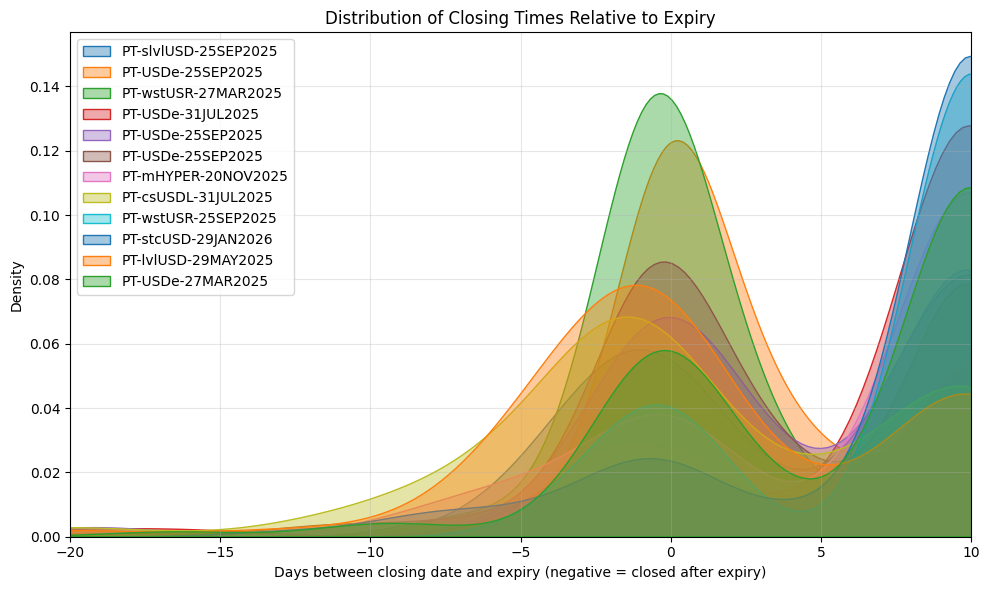

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_expiry_distributions(market_info_list, x_range=(-20, 10)):
    """
    Plot KDE distributions of days between closing date and expiry for multiple markets.
    
    Parameters:
    market_info_list: list of dicts with keys 'token' and 'positions_df' (DataFrame)
    x_range: tuple (min, max) for x-axis limits
    """
    plt.figure(figsize=(10, 6))
    
    for info in market_info_list:
        token = info['token']
        df = info['positions_df']
        if df.empty or 'days_to_expiry_after_close' not in df.columns:
            print(f"No data for {token}, skipping")
            continue
        
        data = df['days_to_expiry_after_close'].dropna()
        if len(data) < 2:
            print(f"Not enough data for {token}, skipping")
            continue
        
        # Clip data to x_range for KDE calculation (optional, but improves visual)
        clipped = data.clip(lower=x_range[0], upper=x_range[1])
        sns.kdeplot(clipped, label=token, fill=True, alpha=0.4)
    
    plt.xlim(x_range)
    plt.xlabel('Days between closing date and expiry (negative = closed after expiry)')
    plt.ylabel('Density')
    plt.title('Distribution of Closing Times Relative to Expiry')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_expiry_distributions(big_markets)

**Who close the position early?**

In [154]:
late_closing_raw_df

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol,base_apy,implied_apy,underlying_apy,leverage_factor
203,0xe4dc8e1db7d28def74b85891bac78bd1c3484763b6f9...,MarketSupplyCollateral,1743725531,0x0C9b7a460609B1016F276f86a39Ce0501788dCA1,2552582325280021347926,2472.362042,0,0,eth_PT-USDe-31JUL2025_dai,2025-04-04 00:12:11,0x760b14c9003f08ac4bf0cfb02596ee4d6f0548a4fde5...,1.000031e+07,4.679690e+06,1.000036e+07,4.681736e+06,0.467954,0.468157,2,0.015310,0.007165,0.015314,0.007170,0.968573,0.999648,0.000000,0.000000,0.000000,0.0,0.000000,2552.582325,2472.362042,1999.296000,0.0,0.808943,0.000000,1.131902,position_open,False,0.000166,-0.000123,0.000123,0.000206,-0.000164,-0.000503,position_open,PT-USDe-31JUL2025,DAI,0.055261,0.06604,0,6
204,0xe4dc8e1db7d28def74b85891bac78bd1c3484763b6f9...,MarketBorrow,1743725531,0x0C9b7a460609B1016F276f86a39Ce0501788dCA1,2000000000000000000000,1999.296000,0,0,eth_PT-USDe-31JUL2025_dai,2025-04-04 00:12:11,0x760b14c9003f08ac4bf0cfb02596ee4d6f0548a4fde5...,1.000031e+07,4.679690e+06,1.000036e+07,4.681736e+06,0.467954,0.468157,2,0.015310,0.007165,0.015314,0.007170,0.968573,0.999648,0.000000,0.000000,0.000000,0.0,0.000000,2552.582325,2472.362042,1999.296000,0.0,0.808943,0.000000,1.131902,position_open,False,0.000166,-0.000123,0.000123,0.000206,-0.000164,-0.000503,position_open,PT-USDe-31JUL2025,DAI,0.055261,0.06604,0,6
205,0x91c7668a2c3d6cbaff31e57071a02f3e79da78e1cdbb...,MarketSupplyCollateral,1743725939,0x0C9b7a460609B1016F276f86a39Ce0501788dCA1,2042797446058376519128,1978.598228,0,0,eth_PT-USDe-31JUL2025_dai,2025-04-04 00:18:59,0x760b14c9003f08ac4bf0cfb02596ee4d6f0548a4fde5...,1.000036e+07,4.681736e+06,1.000036e+07,4.683178e+06,0.468157,0.468301,2,0.015314,0.007170,0.015317,0.007173,0.968573,0.999648,2552.582325,2472.362042,1999.296000,0.0,0.808943,4595.379771,4450.960270,3439.568845,0.0,0.773042,1.131902,1.184469,borrow_more_w_collateral,False,0.000166,-0.000123,0.000123,0.000206,-0.000164,-0.000503,borrow_more_w_collateral,PT-USDe-31JUL2025,DAI,0.055261,0.06604,0,6
206,0x91c7668a2c3d6cbaff31e57071a02f3e79da78e1cdbb...,MarketBorrow,1743725939,0x0C9b7a460609B1016F276f86a39Ce0501788dCA1,1440780000000000000000,1440.272845,0,0,eth_PT-USDe-31JUL2025_dai,2025-04-04 00:18:59,0x760b14c9003f08ac4bf0cfb02596ee4d6f0548a4fde5...,1.000036e+07,4.681736e+06,1.000036e+07,4.683178e+06,0.468157,0.468301,2,0.015314,0.007170,0.015317,0.007173,0.968573,0.999648,2552.582325,2472.362042,1999.296000,0.0,0.808943,4595.379771,4450.960270,3439.568845,0.0,0.773042,1.131902,1.184469,borrow_more_w_collateral,False,0.000166,-0.000123,0.000123,0.000206,-0.000164,-0.000503,borrow_more_w_collateral,PT-USDe-31JUL2025,DAI,0.055261,0.06604,0,6
207,0x10da716120b0d5052bbffaf6fc57a3ac9d12c9667ceb...,MarketSupplyCollateral,1743726323,0x0C9b7a460609B1016F276f86a39Ce0501788dCA1,1470810183333492434444,1424.586871,0,0,eth_PT-USDe-31JUL2025_dai,2025-04-04 00:25:23,0x760b14c9003f08ac4bf0cfb02596ee4d6f0548a4fde5...,1.000036e+07,4.683178e+06,1.000036e+07,4.684280e+06,0.468301,0.468411,2,0.015317,0.007173,0.015319,0.007176,0.968573,0.999648,4595.379771,4450.960270,3439.568845,0.0,0.773042,6066.189955,5875.547141,4540.791079,0.0,0.773101,1.184469,1.184379,borrow_more_w_collateral,False,0.000166,-0.000123,0.000123,0.000206,-0.000164,-0.000503,borrow_more_w_collateral,PT-USDe-31JUL2025,DAI,0.055261,0.06604,0,6
...

In [169]:
big_markets[market_index]["market_df"]

,timestamp,datetime,total_supply,total_borrow,utilization,borrow_rate,supply_rate,volatility_1h,drawdown_1h,volatility_6h,drawdown_6h,collateral_price,loan_asset_price,avg_health_factor,borrow_rate_rolling,supply_rate_rolling,asset_price,base_apy,implied_apy,underlying_apy
0,1741788000,2025-03-12 14:00:00,0.000000,0.00000,0.000000,0.000000,0.000000,0,0,0.0000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.951861,0.047715,0.110083,0
1,1741791600,2025-03-12 15:00:00,1.000000,0.84400,0.844000,0.038133,0.032185,0,0,0.0000,0.0,0.952369,0.999345,1.033839,0.019066,0.016092,0.952369,0.047708,0.110066,0
2,1741795200,2025-03-12 16:00:00,1.000000,0.84400,0.844000,0.038133,0.032185,0,0,0.0000,0.0,0.952369,0.999345,1.033839,0.025422,0.021457,0.952099,0.047780,0.110066,0
3,1741798800,2025-03-12 17:00:00,1.000000,0.84400,0.844000,0.038133,0.032185,0,0,0.0000,0.0,0.952369,0.999345,1.033839,0.028599,0.024139,0.951986,0.048247,0.110688,0
4,1741802400,2025-03-12 18:00:00,1.000000,0.84400,0.844000,0.038133,0.032185,0,0,0.0000,0.0,0.952369,0.999345,1.033839,0.030506,0.025748,0.952018,0.051634,0.112824,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4085,1756494000,2025-08-29 19:00:00,163195.778925,148742.20965,0.911434,0.068259,0.062232,0,0,0.0004,0.0,1.000000,0.999911,0.000000,0.068259,0.062232,1.000000,0.386168,0.344460,0
4086,1756497600,2025-08-29 20:00:00,163195.778925,148742.20965,0.911434,0.068259,0.062232,0,0,0.0004,0.0,1.000000,0.999911,0.000000,0.068259,0.062232,1.000000,0.386168,0.344460,0
4087,1756501200,2025-08-29 21:00:00,163195.778925,148742.20965,0.911434,0.068259,0.062232,0,0,0.0004,0.0,1.000000,0.999911,0.000000,0.068259,0.062232,1.000000,0.386168,0.344460,0
4088,1756504800,2025-08-29 22:00:00,163195.778925,148742.20965,0.911434,0.068259,0.062232,0,0,0.0004,0.0,1.000000,0.999911,0.000000,0.068259,0.062232,1.000000,0.386168,0.344460,0


PT-reUSD-25JUN2026


((223, 10), (223, 10))

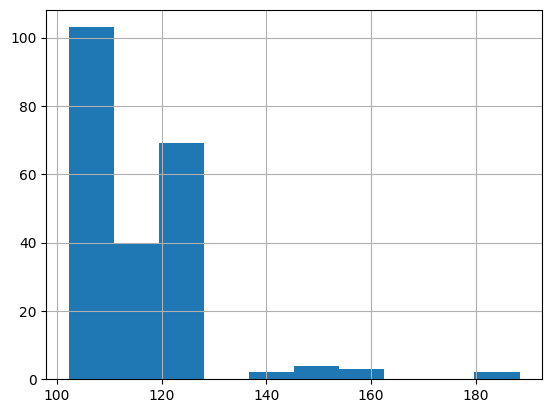

In [183]:
market_index = 7
print(big_markets[market_index]["token"])
positions_df = big_markets[market_index]["positions_df"]
positions_df["days_to_expiry_after_close"].hist()
early_thr = 7
early_closing = positions_df[positions_df["days_to_expiry_after_close"] >= early_thr]
late_closing = positions_df[positions_df["days_to_expiry_after_close"] < early_thr]

early_closing_raw_df = big_markets[market_index]["raw_df"]
early_closing_raw_df = early_closing_raw_df[early_closing_raw_df["user_address"].isin(early_closing["user_address"].unique())]
late_closing_raw_df = big_markets[market_index]["raw_df"]
late_closing_raw_df = late_closing_raw_df[late_closing_raw_df["user_address"].isin(late_closing["user_address"].unique())]

early_closing_raw_df = add_leverage_factor(early_closing_raw_df)
late_closing_raw_df = add_leverage_factor(late_closing_raw_df)

early_closing.shape, positions_df.shape

<Axes: >

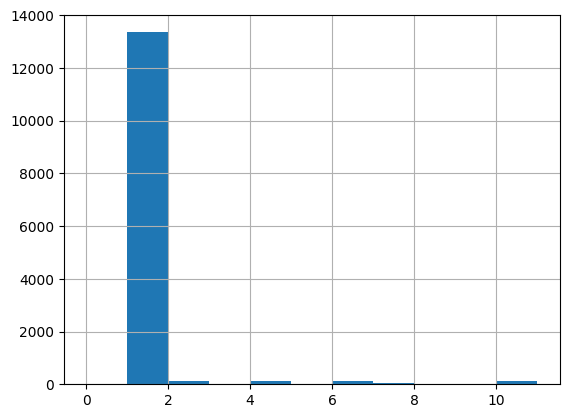

In [184]:
early_closing_raw_df["leverage_factor"].hist()
late_closing_raw_df["leverage_factor"].hist()

<Axes: >

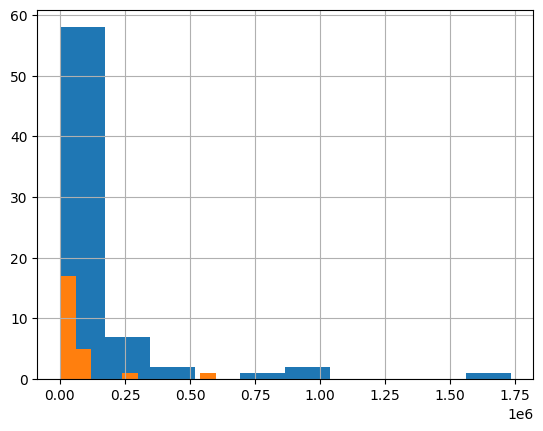

In [153]:
# early_closing["initial_ltv"].hist()
# late_closing["initial_ltv"].hist()

early_closing["initial_debt"].hist()
late_closing["initial_debt"].hist()


<Axes: >

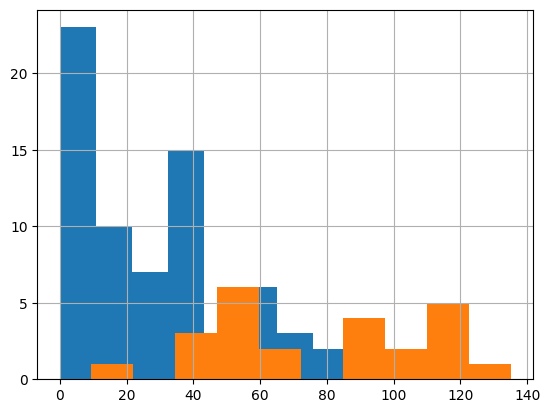

In [166]:
early_closing["position_length_days"].hist()
late_closing["position_length_days"].hist()

In [165]:
# for i in late_closing.sort_values("max_debt", ascending=False)["user_address"].unique()[:20]:
#     plot_user_metrics(
#         big_markets[market_index]["hourly_df"],
#         ['debt', 'implied_apy'],
#         i,
#         # dates_range=("2025-01-01", "2025-10-25"),
#     )

In [187]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

def parse_expiry_from_token(token_name):
    import re
    from datetime import datetime
    match = re.search(r'(\d{1,2}[A-Za-z]{3}\d{4})', token_name)
    if match:
        date_str = match.group(1)
        if len(date_str) == 8:
            date_str = '0' + date_str
        return datetime.strptime(date_str, '%d%b%Y')
    raise ValueError(f"Cannot parse expiry from {token_name}")

def add_leverage_factor(df_actions, window_hours=24):
    df = df_actions.sort_values(['user_address', 'timestamp']).copy()
    open_times = df[df['event_sequence_type'] == 'position_open'].groupby('user_address')['timestamp'].first().to_dict()
    leverage = {}
    for user, open_ts in open_times.items():
        user_df = df[df['user_address'] == user]
        window_end = open_ts + window_hours * 3600
        events = user_df[(user_df['timestamp'] >= open_ts) & (user_df['timestamp'] <= window_end)]
        count = len(events[events['event_sequence_type'] == 'borrow_more_w_collateral'])
        leverage[user] = 1 + count // 2
    df['leverage_factor'] = df['user_address'].map(leverage).fillna(1).astype(int)
    return df

def prepare_user_features(market_info, early_threshold=7):
    token = market_info['token']
    positions_df = market_info['positions_df']
    raw_df = market_info['raw_df']
    market_df = market_info['market_df']
    expiry_date = parse_expiry_from_token(token)
    expiry_ts = expiry_date.timestamp()
    raw_df = add_leverage_factor(raw_df)
    features_list = []
    for idx, row in positions_df.iterrows():
        user = row['user_address']
        open_time = row['opening_date'].timestamp()
        initial_ltv = row['initial_ltv']
        initial_debt = row['initial_debt']
        user_leverage = raw_df[raw_df['user_address'] == user]['leverage_factor'].iloc[0] if len(raw_df[raw_df['user_address'] == user]) > 0 else 1
        days_to_expiry_open = (expiry_ts - open_time) / (24*3600)
        market_row = market_df.iloc[(market_df['timestamp'] - open_time).abs().argsort()[:1]]
        vol = market_row['volatility_6h'].values[0] if not market_row.empty else 0
        borrow_rate = market_row['borrow_rate'].values[0] if not market_row.empty else 0
        implied_apy = market_row['implied_apy'].values[0] if not market_row.empty else 0
        target = 1 if row['days_to_expiry_after_close'] >= early_threshold else 0
        features_list.append({
            'user': user,
            'initial_ltv': initial_ltv,
            'initial_debt': np.log1p(initial_debt),
            'leverage_factor': user_leverage,
            'days_to_expiry_open': days_to_expiry_open,
            'volatility_6h': vol,
            'borrow_rate': borrow_rate,
            'target': target,
            'implied_apy': 'implied_apy',
        })
    return pd.DataFrame(features_list)

def train_early_closing_classifier(market_info_list, early_threshold=7, model_type='xgb'):
    all_data = []
    for info in market_info_list:
        if info["token"] == "PT-reUSD-25JUN2026":
            continue
        df_feat = prepare_user_features(info, early_threshold)
        all_data.append(df_feat)
    combined = pd.concat(all_data, ignore_index=True).dropna()
    X = combined.drop(['user', 'target'], axis=1)
    y = combined['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    if model_type == 'lr':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        model = LogisticRegression(class_weight='balanced', max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        model = xgb.XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        scaler = None
    
    print("=== OVERALL CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred))
    print(f"Overall ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
    
    print("\n=== PER MARKET METRICS (TEST SET ONLY) ===")
    test_users = X_test.index if hasattr(X_test, 'index') else range(len(X_test))
    for info in market_info_list:
        token = info['token']
        df_feat = prepare_user_features(info, early_threshold)
        if df_feat.empty:
            print(f"{token}: No data")
            continue
        
        # Get test indices for this market
        test_mask = df_feat.index.isin(test_users)
        X_market = df_feat.drop(['user', 'target'], axis=1)
        y_market = df_feat['target']
        
        X_market_test = X_market[test_mask]
        y_market_test = y_market[test_mask]
        
        if X_market_test.empty:
            print(f"{token}: No test samples")
            continue
        
        if model_type == 'lr':
            X_market_scaled = scaler.transform(X_market_test)
            y_pred_market = model.predict(X_market_scaled)
            y_prob_market = model.predict_proba(X_market_scaled)[:,1]
        else:
            y_pred_market = model.predict(X_market_test)
            y_prob_market = model.predict_proba(X_market_test)[:,1]
        
        from sklearn.metrics import precision_score, recall_score
        prec = precision_score(y_market_test, y_pred_market, zero_division=0)
        rec = recall_score(y_market_test, y_pred_market, zero_division=0)
        try:
            auc = roc_auc_score(y_market_test, y_prob_market)
        except Exception as e:
            auc=0
        print(f"{token}: N_test={len(y_market_test)}, Class1_test={(y_market_test==1).sum()}, Precision={prec:.3f}, Recall={rec:.3f}, ROC-AUC={auc:.3f}")
    
    return model, scaler, combined


model, scaler, feature_df = train_early_closing_classifier(
    market_info_list=big_markets,
    early_threshold=7,
    model_type='xgb'  # or 'lr' for logistic regression
)

# To see feature importance for XGBoost
if hasattr(model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': ['initial_ltv', 'log_initial_debt', 'leverage_factor', 'days_to_expiry_open', 'volatility_6h', 'borrow_rate', 'implied_apy'],
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    print(importance_df)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:implied_apy: object

In [174]:
for i in big_markets:
    print(i["positions_df"].shape)

(76, 10)
(128, 10)
(51, 10)
(95, 10)
(116, 10)
(216, 10)
(77, 10)
(223, 10)
(107, 10)
(60, 10)
(129, 10)
(85, 10)
(122, 10)
